In [1]:
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision.transforms import Compose, ToTensor, Normalize
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib为黑色主题
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': 'black',
    'axes.facecolor': 'black',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'text.color': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'grid.color': '#444444',
    'grid.alpha': 0.3,
    'legend.facecolor': 'black',
    'legend.edgecolor': 'white',
})

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)


# <font color="#00FFFF" >**第五章 神经网络训练技巧深度解析**</font>

## **本章内容**

> 1. 梯度消失、梯度爆炸及其解决方案
> 2. 优化器改进与学习率调整
> 3. 过拟合处理
> 4. 超参数选取实践指南


##  <font color="#FFEA00" >**第1节 梯度消失、梯度爆炸及其解决方案**</font>


### **<font color="#39FF14">一、梯度消失与梯度爆炸现象</font>**

#### <font color="#CCFF00">**梯度消失（Vanishing Gradients）**</font>

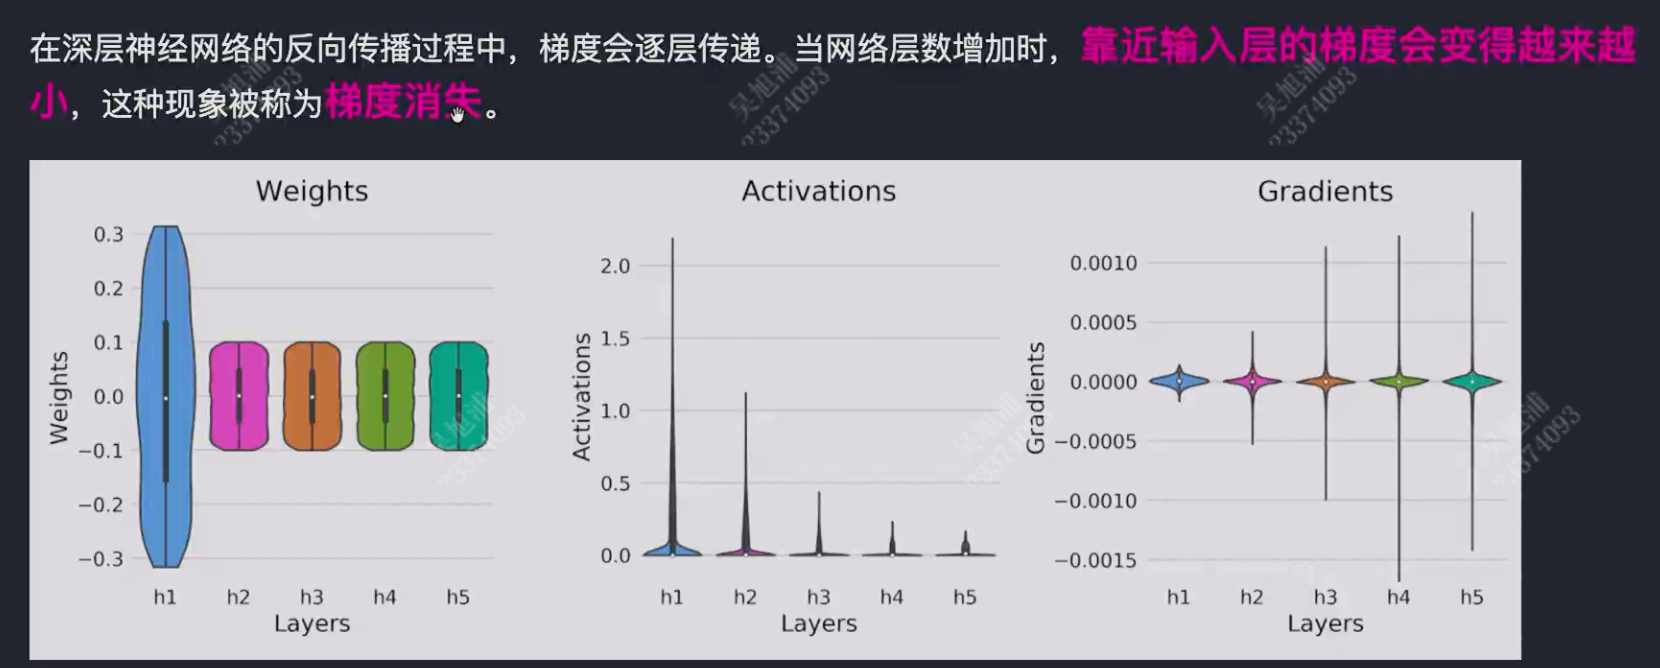

**为什么会发生？**
- 反向传播使用链式法则，梯度会逐层相乘
- 如果每层的梯度都小于1，多次相乘后会指数级减小
- 结果：靠近输入层的权重几乎不更新，模型无法学习

**危害**：
- 模型训练停滞，损失不再下降
- 浅层（靠近输入）的特征无法得到有效学习

#### <font color="#CCFF00">**梯度爆炸（Exploding Gradients）**</font>

与梯度消失相反，梯度爆炸是指在反向传播过程中，梯度变得越来越大，最终导致<font color="#FF00A0">**数值溢出**</font>。

**识别方法**：
- 训练过程中损失突然变成 **NaN**（Not a Number）

**为什么会发生？**
- 如果每层的梯度都大于1，多次相乘后会指数级增长
- 学习率过高
- 目标变量值范围过大（如回归问题中目标值从-400到400）


### **<font color="#39FF14" size=6 >二、梯度爆炸解决方案：梯度裁剪（Gradient Clipping）</font>**

#### <font color="#CCFF00">**什么是梯度裁剪？**</font>

<font color="#FF00A0">**梯度裁剪**</font>是一种解决梯度爆炸的技术，通过限制梯度的大小来防止其无限增长。

<font color="#FF00A0">**基本思想**</font>：设置一个阈值，当梯度的绝对值超过阈值时，将其裁剪到阈值范围内。

<font color="#FF00A0">**两种主要方法**</font>：
1. **Value Clipping**（元素级裁剪）：逐个元素限制梯度值
2. **Norm Clipping**（范数裁剪）：限制梯度向量的整体范数

#### <font color="#CCFF00">**Value Clipping（元素级裁剪）**</font>

将每个梯度元素限制在 $[-\text{clip\_value}, +\text{clip\_value}]$ 范围内。

In [2]:
# Value Clipping示例
import torch.nn.utils as nn_utils

# 创建示例参数和梯度
param = nn.Parameter(torch.tensor([[2.5], [0.8]]))
param.grad = torch.tensor([[2.5], [0.8]])

print("原始梯度:")
print(param.grad)

# Value clipping（限制在[-1.0, 1.0]）
nn_utils.clip_grad_value_(param, clip_value=1.0)

print("\n裁剪后梯度 (clip_value=1.0):")
print(param.grad)
print("\n观察：第一个梯度从2.5被裁剪到1.0")

原始梯度:
tensor([[2.5000],
        [0.8000]])

裁剪后梯度 (clip_value=1.0):
tensor([[1.0000],
        [0.8000]])

观察：第一个梯度从2.5被裁剪到1.0



**特点**：
- 实现简单，计算快速
- 缺点：会改变梯度的方向
- 适用：大多数情况

#### <font color="#CCFF00">**Norm Clipping（范数裁剪）**</font>

计算所有梯度的整体范数，如果超过阈值则按比例缩放。

**特点**：
- 保持梯度的方向不变
- 只调整梯度的整体大小
- 计算稍复杂，但效果更好


In [3]:
# Norm Clipping示例
param2 = nn.Parameter(torch.tensor([[2.5], [0.8]]))
param2.grad = torch.tensor([[2.5], [0.8]])

print("原始梯度:")
print(param2.grad)
print(f"原始范数: {param2.grad.norm():.4f}")

# Norm clipping（限制范数为1.0）
nn_utils.clip_grad_norm_(param2, max_norm=1.0, norm_type=2)

print("\n裁剪后梯度 (max_norm=1.0):")
print(param2.grad)
print(f"裁剪后范数: {param2.grad.norm():.4f}")
print(f"\n缩放因子: {1.0/2.6249:.4f}")

原始梯度:
tensor([[2.5000],
        [0.8000]])
原始范数: 2.6249

裁剪后梯度 (max_norm=1.0):
tensor([[0.9524],
        [0.3048]])
裁剪后范数: 1.0000

缩放因子: 0.3810


 钩子函数 （再找地方看）

#### <font color="#CCFF00">**Backward Hooks（反向传播中裁剪）**</font>

对于RNN等特殊网络，需要在反向传播过程中（实时）裁剪梯度。

**实现方法**：使用 `register_hook()` 注册梯度裁剪函数

**适用场景**：
- 循环神经网络（RNN、LSTM、GRU）
- 需要精确控制梯度流的场景

In [4]:
# Backward Hooks实现
def clip_backprop(model, clip_value):
    """
    使用backward hooks在反向传播中裁剪梯度
    """
    handles = []
    for p in model.parameters():
        if p.requires_grad:
            func = lambda grad: torch.clamp(grad, -clip_value, clip_value)
            handle = p.register_hook(func)
            handles.append(handle)
    return handles

def remove_hooks(handles):
    """移除所有hooks"""
    for handle in handles:
        handle.remove()

print("Backward hooks函数定义完成！")
print("\n使用示例:")
print("  handles = clip_backprop(model, clip_value=1.0)")
print("  # 训练...")
print("  remove_hooks(handles)")

Backward hooks函数定义完成！

使用示例:
  handles = clip_backprop(model, clip_value=1.0)
  # 训练...
  remove_hooks(handles)


#### <font color="#CCFF00">**梯度爆炸解决方案小结**</font>

<font color="#FF00A0" size=5>**除梯度裁剪外的解决方案**</font>

| 方案类别 | 具体方法 | 核心原理 | 适用场景 |
|:--------:|:---------|:---------|:---------|
| **权重正则化** | L2正则化/权重衰减 | 限制权重大小，间接约束梯度 | 所有网络 |
| **改进初始化** | 正交初始化、LSUV、Fixup | 保持梯度范数在反向传播中稳定 | 极深网络 |
| **归一化技术** | Batch Norm、Layer Norm、Spectral Norm | 将激活值标准化，约束反向梯度 | 推荐首选 |
| **架构改进** | Pre-activation、DenseNet、Highway | 改善梯度通路，分散梯度流 | 深层网络 |
| **优化器调整** | Adam、Lookahead | 自适应学习率自动调节步长 | 配合其他方法 |
| **激活函数** | GELU、Mish等自门控激活 | 平滑且有界，梯度更温和 | 替代ReLU |

**实践建议优先级**：
1. **首选**：Batch/Layer Norm + He/Xavier初始化（治本）
2. **其次**：梯度裁剪作为保险（治标，设置阈值如1-10）
3. **深度网络**：考虑Pre-Norm、Fixup初始化或更好的残差设计
4. **特殊情况**（GAN、RNN）：谱归一化、正交初始化

<font color="#FF00A0" size=5>**洞察：**</font>梯度裁剪是一个症状治疗（治标）的手段，而归一化、良好的初始化、合理的架构设计才是病因治疗（治本）。

### **<font color="#39FF14" size=6 >三、梯度消失解决方案</font>**

#### <font color="#CCFF00">**1.选择合适的参数初始化方案**</font>

##### <font color="#00ffbf">**可选的初始化方案**</font>

| 方法 | 适用激活函数 | 公式 | 特点 |提出者 | PyTorch函数 |
|:------:|:--------------:|:----:|:----:|:------:|:------------|
| **高斯分布** | 通用 | $\mathcal{N}(0, 0.01^2)$ | 简单，可能梯度消失 | - | `normal_` |
| **Xavier** | Tanh, Sigmoid | $\mathcal{U}(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}})$ | 保持方差稳定 |Glorot & Bengio | `xavier_uniform_`, `xavier_normal_` |
| **He** | 专为ReLU设计 | $\mathcal{N}(0, \sqrt{\frac{2}{n_{in}}})$ |He et al. | ReLU, LeakyReLU | `kaiming_uniform_`, `kaiming_normal_` |

In [ ]:
##### <font color="#00ffbf">**初始化方案：Xavier (Glorot) 初始化**</font>

由Xavier Glorot和Yoshua Bengio提出，专为**TanH**激活函数设计。

**数学原理**：
从均匀分布中采样：
$$U[-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}]$$

￼$n_{i}$神经元的数量

**PyTorch实现**：
```python
nn.init.xavier_uniform_(tensor)
nn.init.xavier_normal_(tensor)
```

**适用场景**：使用TanH、Sigmoid等饱和激活函数时

##### <font color="#00ffbf">**初始化方案：Kaiming (He) 初始化**</font>

由Kaiming He（ResNet作者）等人提出，专为**ReLU**激活函数设计。

**数学原理**：

- kaiming_normal_从正态分布 $\mathcal{N}(0, \sigma^2)$ 中采样，其中：
  $$\sigma = \sqrt{\frac{2}{n_{in}}}$$

  $n_{in}$ 为输入维度。
  
- kaiming_uniform_均匀分布，采样范围为 $[-\text{bound}, \text{bound}]$，其中 $\text{bound} = \sqrt{3} \cdot \sigma= \sqrt{\frac{6}{n_{in}}}$。

**PyTorch实现**：
```python
nn.init.kaiming_uniform_(tensor, nonlinearity='relu')
nn.init.kaiming_normal_(tensor, nonlinearity='relu')
```

**适用场景**：使用ReLU及其变体（LeakyReLU等）激活函数时

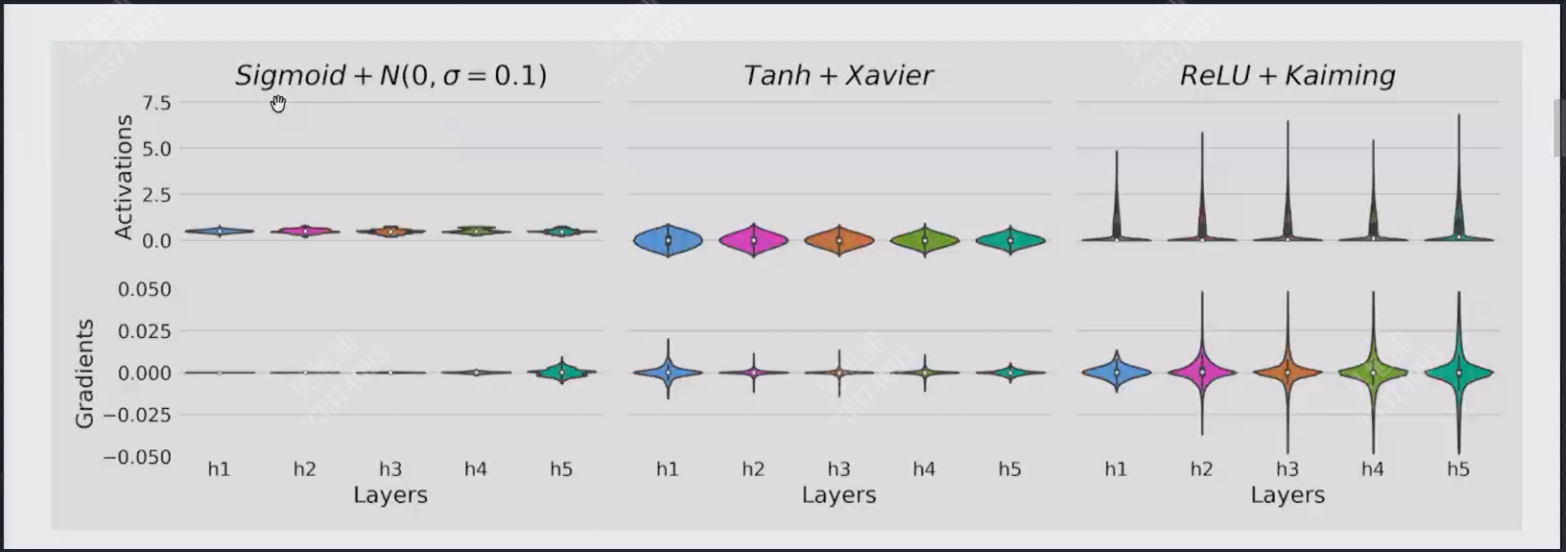

#### <font color="#CCFF00">**2.批归一化（Batch Normalization）也可以使训练更稳定**</font>

##### <font color="#00ffbf">**内部协变量偏移（ICS，Internal Covariate Shift）**</font>

训练中，深度神经网络中间层的数据分布会因为参数的更新导致分布发生变化，这被称为<font color="#FF00A0" size=5>**内部协变量偏移**</font>。

**问题描述**：
- 每一层的输入分布随着前一层参数更新而变化
- ICS可能增加优化难度，使得网络需要适应数据分布的变化，训练困难
- 需要使用较小的学习率，收敛缓慢

<font color="#FF00A0" size=5>**争议：**</font>

ICS对训练的影响并没有那么大，但BN确实可以提升训练稳定性和效率

<font color="#FF00A0" size=5>**批归一化（Batch Normalization）的最初愿景**</font>: 通过BN来减少ICS带来的影响

##### <font color="#00ffbf">**CNN中BN的核心操作**</font>

<font color="#FF00A0">**1. 维度处理**</font>

对于卷积层的输出，形状为 `[Batch, Channel, Height, Width]`，BN是**对每个Channel独立进行**的

<font color="#FF00A0">**2. 具体计算步骤**</font>

对于第 $c$ 个通道，给定mini-batch数据 $X \in \mathbb{R}^{N \times C \times H \times W}$：

**Step 1: 计算均值**
$$\mu_c = \frac{1}{N \times H \times W} \sum_{n=1}^{N} \sum_{h=1}^{H} \sum_{w=1}^{W} x_{n,c,h,w}$$

**Step 2: 计算方差**
$$\sigma_c^2 = \frac{1}{N \times H \times W} \sum_{n=1}^{N} \sum_{h=1}^{H} \sum_{w=1}^{W} (x_{n,c,h,w} - \mu_c)^2$$

**Step 3: 标准化**
$$\hat{x}_{n,c,h,w} = \frac{x_{n,c,h,w} - \mu_c}{\sqrt{\sigma_c^2 + \epsilon}}$$

**Step 4: 缩放和平移（可学习参数）**
$$y_{n,c,h,w} = \gamma_c \cdot \hat{x}_{n,c,h,w} + \beta_c$$

其中：
- $\gamma$（gamma）：缩放参数，初始化为1
- $\beta$（beta）：平移参数，初始化为0
- $\gamma_c, \beta_c$：每个通道一对，共 $2C$ 个可学习参数
- $\epsilon$：数值稳定性常数（通常 $10^{-5}$）


若 $\gamma_{c}=\sqrt{\sigma_c^2 + \epsilon}$ 且 $\beta_{c} = \mu_c$，则：

  $$y_{n,c,h,w} = \sqrt{\sigma_c^2 + \epsilon} \cdot \frac{x_{n,c,h,w} - \mu_c}{\sqrt{\sigma_c^2 + \epsilon}} + \mu_c = x_{n,c,h,w}$$

  即恢复到该通道的**原始激活值**（恒等变换）。

BN的设置可学习参数的目的是：让 $\gamma, \beta$ 通过训练自动学习最优值，而不是真的想恢复原始分布。这说明BN具有良好的表达能力——它既可以标准化，也可以恢复，或者学习任意线性变换。

##### <font color="#00ffbf">**训练 vs 推理的不同行为**</font>

<font color="#FF00A0">**训练时（Training）**</font>

- 使用**当前batch**的统计量（均值、方差）
- 同时更新**移动平均**统计量，用于推理：

$$\mu_{running} = (1-m) \cdot \mu_{running} + m \cdot \mu_{batch}$$
$$\sigma^2_{running} = (1-m) \cdot \sigma^2_{running} + m \cdot \sigma^2_{batch}$$

<font color="#FF00A0">**推理时（Eval）**</font>

- 使用**训练时累积的移动平均**统计量（$\mu_{running}, \sigma^2_{running}$）
- 不再计算batch统计量
- 确保输出确定性（相同输入始终产生相同输出）

<font color="#FF00A0">**关键区别**</font>：训练时统计量随batch变化，推理时固定使用训练累积值

##### <font color="#00ffbf">**BN在CNN中的位置**</font>
<font color="#FF00A0">**通常位置**</font>：并无定论

- **通常**应用在非线性层之前（也可以放在激活函数之后），根据实践经验（Inception中的操作）
- 在激活函数之后理论上也是合理（对下一层的输入进行仿射变换以减轻ICS）
- BN层的作用更倾向于使loss surface平滑，以改进模型训练


```
输入 → [卷积层] → [批归一化] → [ReLU] → 输出
```

##### <font color="#00ffbf">**BN带来的好处**</font>

| 好处 | 说明 |
|:----:|:-----|
| **允许更大学习率** | 梯度不会爆炸/消失，训练更稳定 |
| **减少对初始化的敏感** | 即使初始化不好也能正常训练 |
| **轻微正则化效果** | 每个样本的归一化依赖于同batch其他样本 |
| **加速收敛** | 通常能减少一半的迭代次数 |

<font color="#FF00A0">**核心本质**</font>：BN将每层的输入分布稳定下来，使网络各层可以独立学习，降低了层与层之间的耦合


##### <font color="#00ffbf">**CNN中使用BN的注意事项**</font>

<font color="#FF00A0">**1. 小batch问题**</font>

当batch size太小（如=1或2）时，统计量估计不准确，此时应使用 **GroupNorm** 或 **LayerNorm** 替代

<font color="#FF00A0">**2. 卷积层设置 bias=False**</font>

由于BN已经包含可学习的平移参数 $\beta$，卷积层的偏置项变得冗余，通常设置为 `bias=False`

```python
nn.Conv2d(in_ch, out_ch, kernel_size, bias=False)  # 推荐
nn.BatchNorm2d(out_ch)  # 包含beta参数，out_ch = 通道数
```

<font color="#FF00A0">**3. 迁移学习时的注意事项**</font>

加载预训练权重时，BN的running mean/var也要一起加载。

##### <font color="#00ffbf">**BN可以补偿不良初始化**</font>

批归一化（Batch Normalization）不仅可以加速训练，还能<font color="#FF00A0">**补偿不良初始化**</font>带来的影响。

##### <font color="#00ffbf">**BasicConv2d结构**</font>

在Inception等现代架构中，通常使用<font color="#FF00A0">**BasicConv2d**</font>结构，将卷积、批归一化和激活函数组合：

**结构顺序**：卷积层 → 批归一化 → 激活函数
- 批归一化放在卷积之后，激活函数之前
- 这种顺序被证明效果最好

In [5]:
# BasicConv2d实现
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(BasicConv2d, self).__init__()
        # 卷积层（不使用偏置，因为BN会处理）
        self.conv = nn.Conv2d(
            in_channels, out_channels, bias=False, **kwargs
        )
        # 批归一化层
        self.bn = nn.BatchNorm2d(out_channels, eps=0.001)
    
    def forward(self, x):
        x = self.conv(x)      # 卷积
        x = self.bn(x)        # 批归一化
        return F.relu(x, inplace=True)  # ReLU激活

# 测试BasicConv2d
basic_conv = BasicConv2d(3, 64, kernel_size=3, padding=1)
test_input = torch.randn(2, 3, 28, 28)
output = basic_conv(test_input)
print(f"BasicConv2d结构:\n{basic_conv}")
print(f"\n输入形状: {test_input.shape}")
print(f"输出形状: {output.shape}")

BasicConv2d结构:
BasicConv2d(
  (conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
)

输入形状: torch.Size([2, 3, 28, 28])
输出形状: torch.Size([2, 64, 28, 28])


##### <font color="#00ffbf">**批归一化与数据标准化的区别**</font>

批归一化（Batch Normalization）与数据标准化有<font color="#FF00A0">**六点**</font>重要区别：



| 特性 | 数据标准化（输入层） | 批归一化（中间层） |
  |:----:|:--------------------:|:------------------:|
  | **计算对象** | 原始像素值 [N,C,H,W] | 卷积后的激活值 [N,C,H,W] |
  | **统计量来源** | 整个训练集预计算（如ImageNet的mean=[0.485, 0.456, 0.406]） | 当前batch实时计算 |
  | **参数量** | 固定值，不参与训练 | γ, β 可学习，每通道2个参数 |
  | **更新方式** | 训练前算一次，固定不变 | 每个iteration更新，同时维护移动平均 |
  | **计算范围** | 所有图片的每个通道（全集统计） | 当前batch的每个通道（batch统计） |

**批归一化的优势**：
1. 允许使用更大的学习率
2. 加速模型收敛
3. 起到轻微正则化作用（因batch统计的随机性）
4. 降低对初始化的敏感度

##### <font color="#00ffbf">**BN对模型的正则化效果**</font>

- 对于某个训练样本，在不同的epoch，因为batch数据的不同（batch统计量的波动），使normalization的输出不同，增加了噪音，提升泛化性。

解读：
- BN的正则化效果，提升了模型的范化能力
- 同样学习率下，BN可以加速训练
- BN允许使用更大的学习率（5倍/30倍），反而收敛最快,有效解决了大学习率导致的梯度不稳定问题
- 有BN的使用Sigmoid激活函数的网络在深层几乎无法训练（梯度消失），BN补偿了Sigmoid的缺陷

BN效果好的真正原因还有<font color="#FF00A0">**争议**</font>（Santurkar, Tsipras, llyas, Madry, NeurIPS 2018），但效果是真的好

| 层级类型 | 推荐做法 | 说明 |
  |:--------:|:--------:|:-----|
  | **卷积层** | **只用BN**<br>不用Dropout | • BN的正则化效果已足够<br>• Dropout收益低 |
  | **全连接层** | **BN 或 Dropout**<br>或只用BN | • 参数量大，易过拟合<br>• Dropout仍是有效正则化手段<br>• 现代网络（ResNet等）也可只用BN |

  > 💡 **经验法则**：卷积层标配 BN；全连接层视情况加 Dropout，参数多/数据少时建议加。


##### <font color="#00ffbf">**其他归一化技巧**</font>

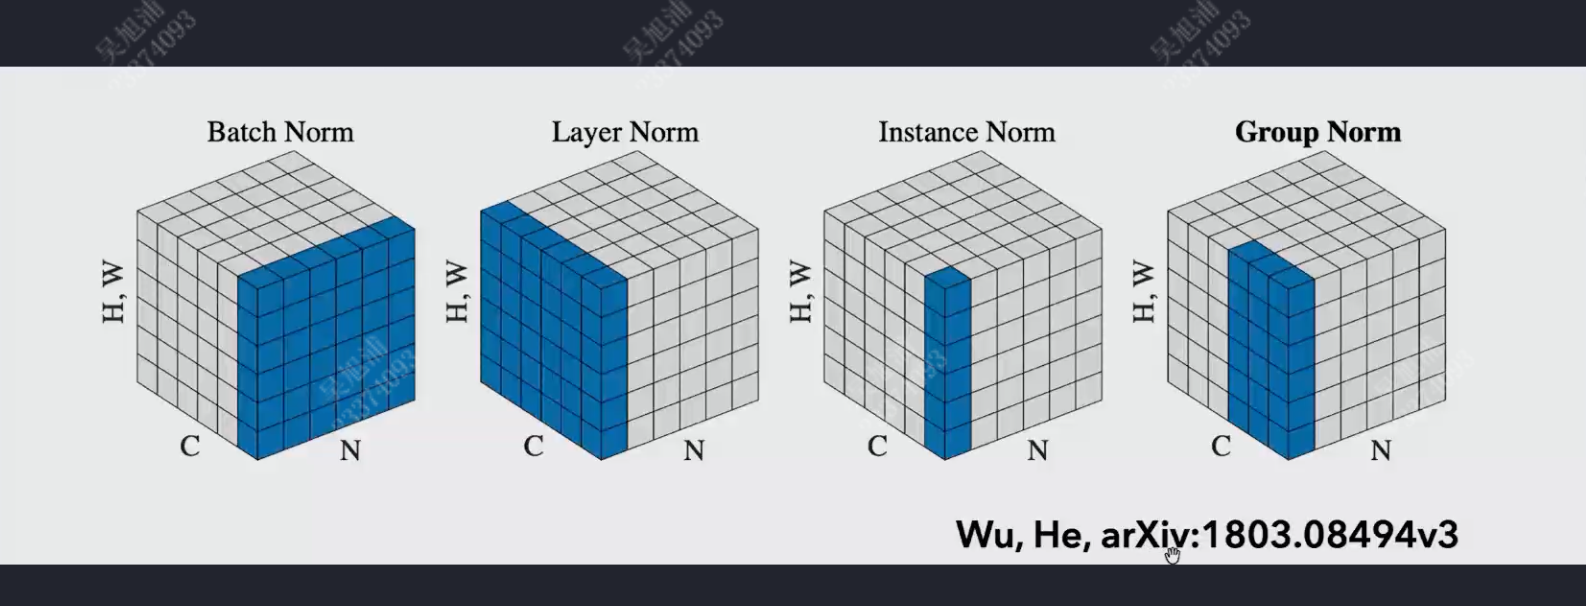

- 都有同样的线性变换形式，但是针对不同的维度
- 批归一化（Batch norm）用于CNN
- 层归一化（Layer norm）用于RNN
- 实例归一化（Instance norm）用于图像风格化
- 群归一化（Group norm）用于CNN处理批较小的情况

### **<font color="#39FF14" size=6 >梯度问题解决方案总结</font>**


| 问题 | 解决方案 | 适用场景 |
|:----:|:---------|:---------|
| **梯度消失** |  **批归一化（BN）**：稳定分布、允许更大学习率、降低初始化敏感度 | **任何网络（推荐首选）** |
|  |  Xavier/Kaiming初始化（注意⚠️与激活函数正确匹配） | 深层网络 |
| **梯度爆炸** |  **归一化技术**（BN/LayerNorm/Spectral Norm） | **推荐首选（治本）** |
|  |  **权重正则化**（L2/Weight Decay） | 所有网络 |
|  | **梯度裁剪**（Norm/Value Clipping） | RNN/深层网络（治标） |
|  | 降低学习率 | 所有网络 |
|  | 标准化目标值 | 回归问题 |

#### <font color="#CCFF00">**最佳实践建议**</font>

1. **正确选择初始化方案**
   - TanH/Sigmoid → Xavier初始化
   - ReLU → Kaiming初始化

2. **优先使用批归一化（BN）**
   - 可以补偿不良初始化
   - 允许使用更大的学习率
   - 提供轻微正则化效果
   - <font color="#FF00A0">注意</font>：训练用batch统计量，推理用移动平均

3. **遇到梯度消失时**
   - 检查激活函数选择（避免Sigmoid/Tanh导致的饱和）
   - 使用批归一化稳定中间层分布
   - 尝试残差连接改善梯度流
   - 监控各层梯度范数，定位消失位置

4. **遇到梯度爆炸时**
   - **治本**：使用归一化技术（BN/LayerNorm/Spectral Norm）、权重正则化（L2/Weight Decay）、改进初始化
   - **治标**：梯度裁剪作为保险（推荐Norm Clipping）
   - 检查目标变量范围、降低学习率

5. **监控梯度大小**
   - 打印各层梯度范数：`p.grad.norm()`
   - 使用TensorBoard可视化梯度分布
   - 设置梯度爆炸报警阈值（如>100）

##  <font color="#FFEA00" >**第2节 优化器改进与学习率调整**</font>

在解决了梯度消失/爆炸问题后，我们需要关注如何高效地收敛到最优解。学习率的选择直接影响优化效率：
- 学习率**太小**：收敛缓慢，训练时间过长
- 学习率**太大**：训练不稳定，损失可能发散

可以从两个维度优化学习率：
1) 优化器层面——使用自适应学习率优化器（如Adam）
2) 训练策略层面——使用学习率调度器动态调整

### **<font color="#39FF14" size=6 >一、考虑动量的优化器</font>**

- 目标函数的形式通常是狭长且浅的沟壑
- 在深度网络中，目标函数的局部最优点经常以这种形式呈现，所以标准的随机梯度下降算法通常会在“沟壑”两侧反复<font color="#FF00A0">**震荡**</font>

#### <font color="#CCFF00">**动量（Momentum）**</font>

<font color="#FF00A0">**动量**</font>：迫使目标函数沿着"沟壑"快速下降的方法（冲量/“惯性”）

<font color="#FF00A0">**动量法的参数更新过程**</font>：

  $$\boldsymbol{v}=\gamma \boldsymbol{v}-\alpha \nabla_{\boldsymbol{\theta}} J\left(\boldsymbol{\theta} ; \boldsymbol{x}^{(i)}, \boldsymbol{t}^{(i)}\right)$$

  $$\boldsymbol{\theta}=\boldsymbol{\theta}+\boldsymbol{v}$$

  其中：
  - $\boldsymbol{v}$：速度向量（累积的历史梯度/"动量"）
  - $\gamma \in(0,1]$：动量系数，决定了之前迭代的梯度以多大程度参与到当前的更新中（"惯性"大小）
  - 第一步计算**新的速度**，第二步用速度**更新参数**


<font color="#FF00A0" size=5>**新的速度 = 惯性（历史积累方向） + 当前坡度影响（当前梯度方向）**</font>

#### <font color="#CCFF00">**Nesterov加速梯度 (NAG，Nesterov Accelerated Gradient)**</font>

Nesterov动量是对标准动量的改进，由俄罗斯数学家 Yurii Nesterov 在1983年提出的优化算法：

<font color="#FF00A0">**标准动量**</font>：先计算当前梯度，再与历史动量融合更新

<font color="#FF00A0">**Nesterov动量**</font>：先"冲"到预估位置（$\theta + \gamma v$），在那里看梯度，再调整

**更新公式**：

$$
v = \gamma v - \alpha \nabla_\theta J(\theta + \gamma v) \\n
\theta = \theta + v
$$

<font color="#FF00A0" >**核心区别**</font>：标准动量在当前位置看梯度；Nesterov先"展望"一步（$\theta + \gamma v$），在展望位置看梯度，提前感知变化,及时调整，避免冲过头

**数学对比**：
```
标准动量：                    Nesterov:
g = ∇J(θ)                     θ_lookahead = θ + γv    （展望位置）
v = γv - α·g                  g = ∇J(θ_lookahead)     （在展望处算梯度）
θ = θ + v                     v = γv - α·g
                              θ = θ + v
```

**在PyTorch中使用**：
Nesterov通常与SGD结合使用，称为 SGD with Nesterov momentum
```python
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,        # 动量系数
    nesterov=True        # 启用Nesterov（默认False）
)
```

<font color="#FF00A0" >**优势**</font>：提前感知梯度变化，避免冲过头，收敛更稳定

<font color="#FF00A0" >**实际效果**</font>：

- 在CNN架构的大规模图像分类任务中中，Nesterov + 适当学习率调度，效果往往优于标准Adam
- 特别是在ImageNet等大型数据集上训练ResNet时，SGD+momentum配合学习率调度（cosine/step）是ResNet训练的标准配置

### **<font color="#39FF14" size=6 >二、自适应学习率的优化器</font>**

动量解决了"方向"问题，但所有参数使用<font color="#FF00A0">**统一的学习率**</font>，可能出现：

<font color="#FF00A0">**问题场景**</font>：
  - 参数A（梯度大）：统一学习率 → 更新过大 → 可能震荡
  - 参数B（梯度小）：统一学习率 → 更新过小 → 更新缓慢

<font color="#FF00A0">**解决方案**</font>：<font color="#f6ff00">**自适应学习率**</font>

  让每个参数拥有**自己的学习率**，根据历史梯度自动调整：
  - 梯度大的参数 → 学习率自动减小
  - 梯度小的参数 → 学习率自动增大

- 自适应学习率的思想催生了一系列优化器：<font color="#FF00A0">**Adagrad**</font>（累积梯度平方）、<font color="#FF00A0">**RMSProp**</font>（引入遗忘）、<font color="#FF00A0">**Adam**</font>（结合动量+自适应）

#### <font color="#CCFF00">**Adagrad**</font>

一种<font color="#FF00A0">**自适应学习率**</font>算法（Duchi et al. 2011）

<font color="#FF00A0">**更新过程：**</font>逐元素更新

$$\boldsymbol{c}=\boldsymbol{c}+\boldsymbol{g}^{2}$$
$$\boldsymbol{\theta}=\boldsymbol{\theta}-\eta \frac{\boldsymbol{g}}{\sqrt{\boldsymbol{c}+\epsilon}}$$

其中：
- $\boldsymbol{g}$为梯度，记为：$\boldsymbol{g}=\nabla_{\boldsymbol{\theta}} J\left(\boldsymbol{\theta} ; \boldsymbol{x}^{(i)}, \boldsymbol{t}^{(i)}\right)$
- $\boldsymbol{c}$积攒历史梯度的平方
- $\epsilon$数值稳定性常数通常取$10^{-8}$

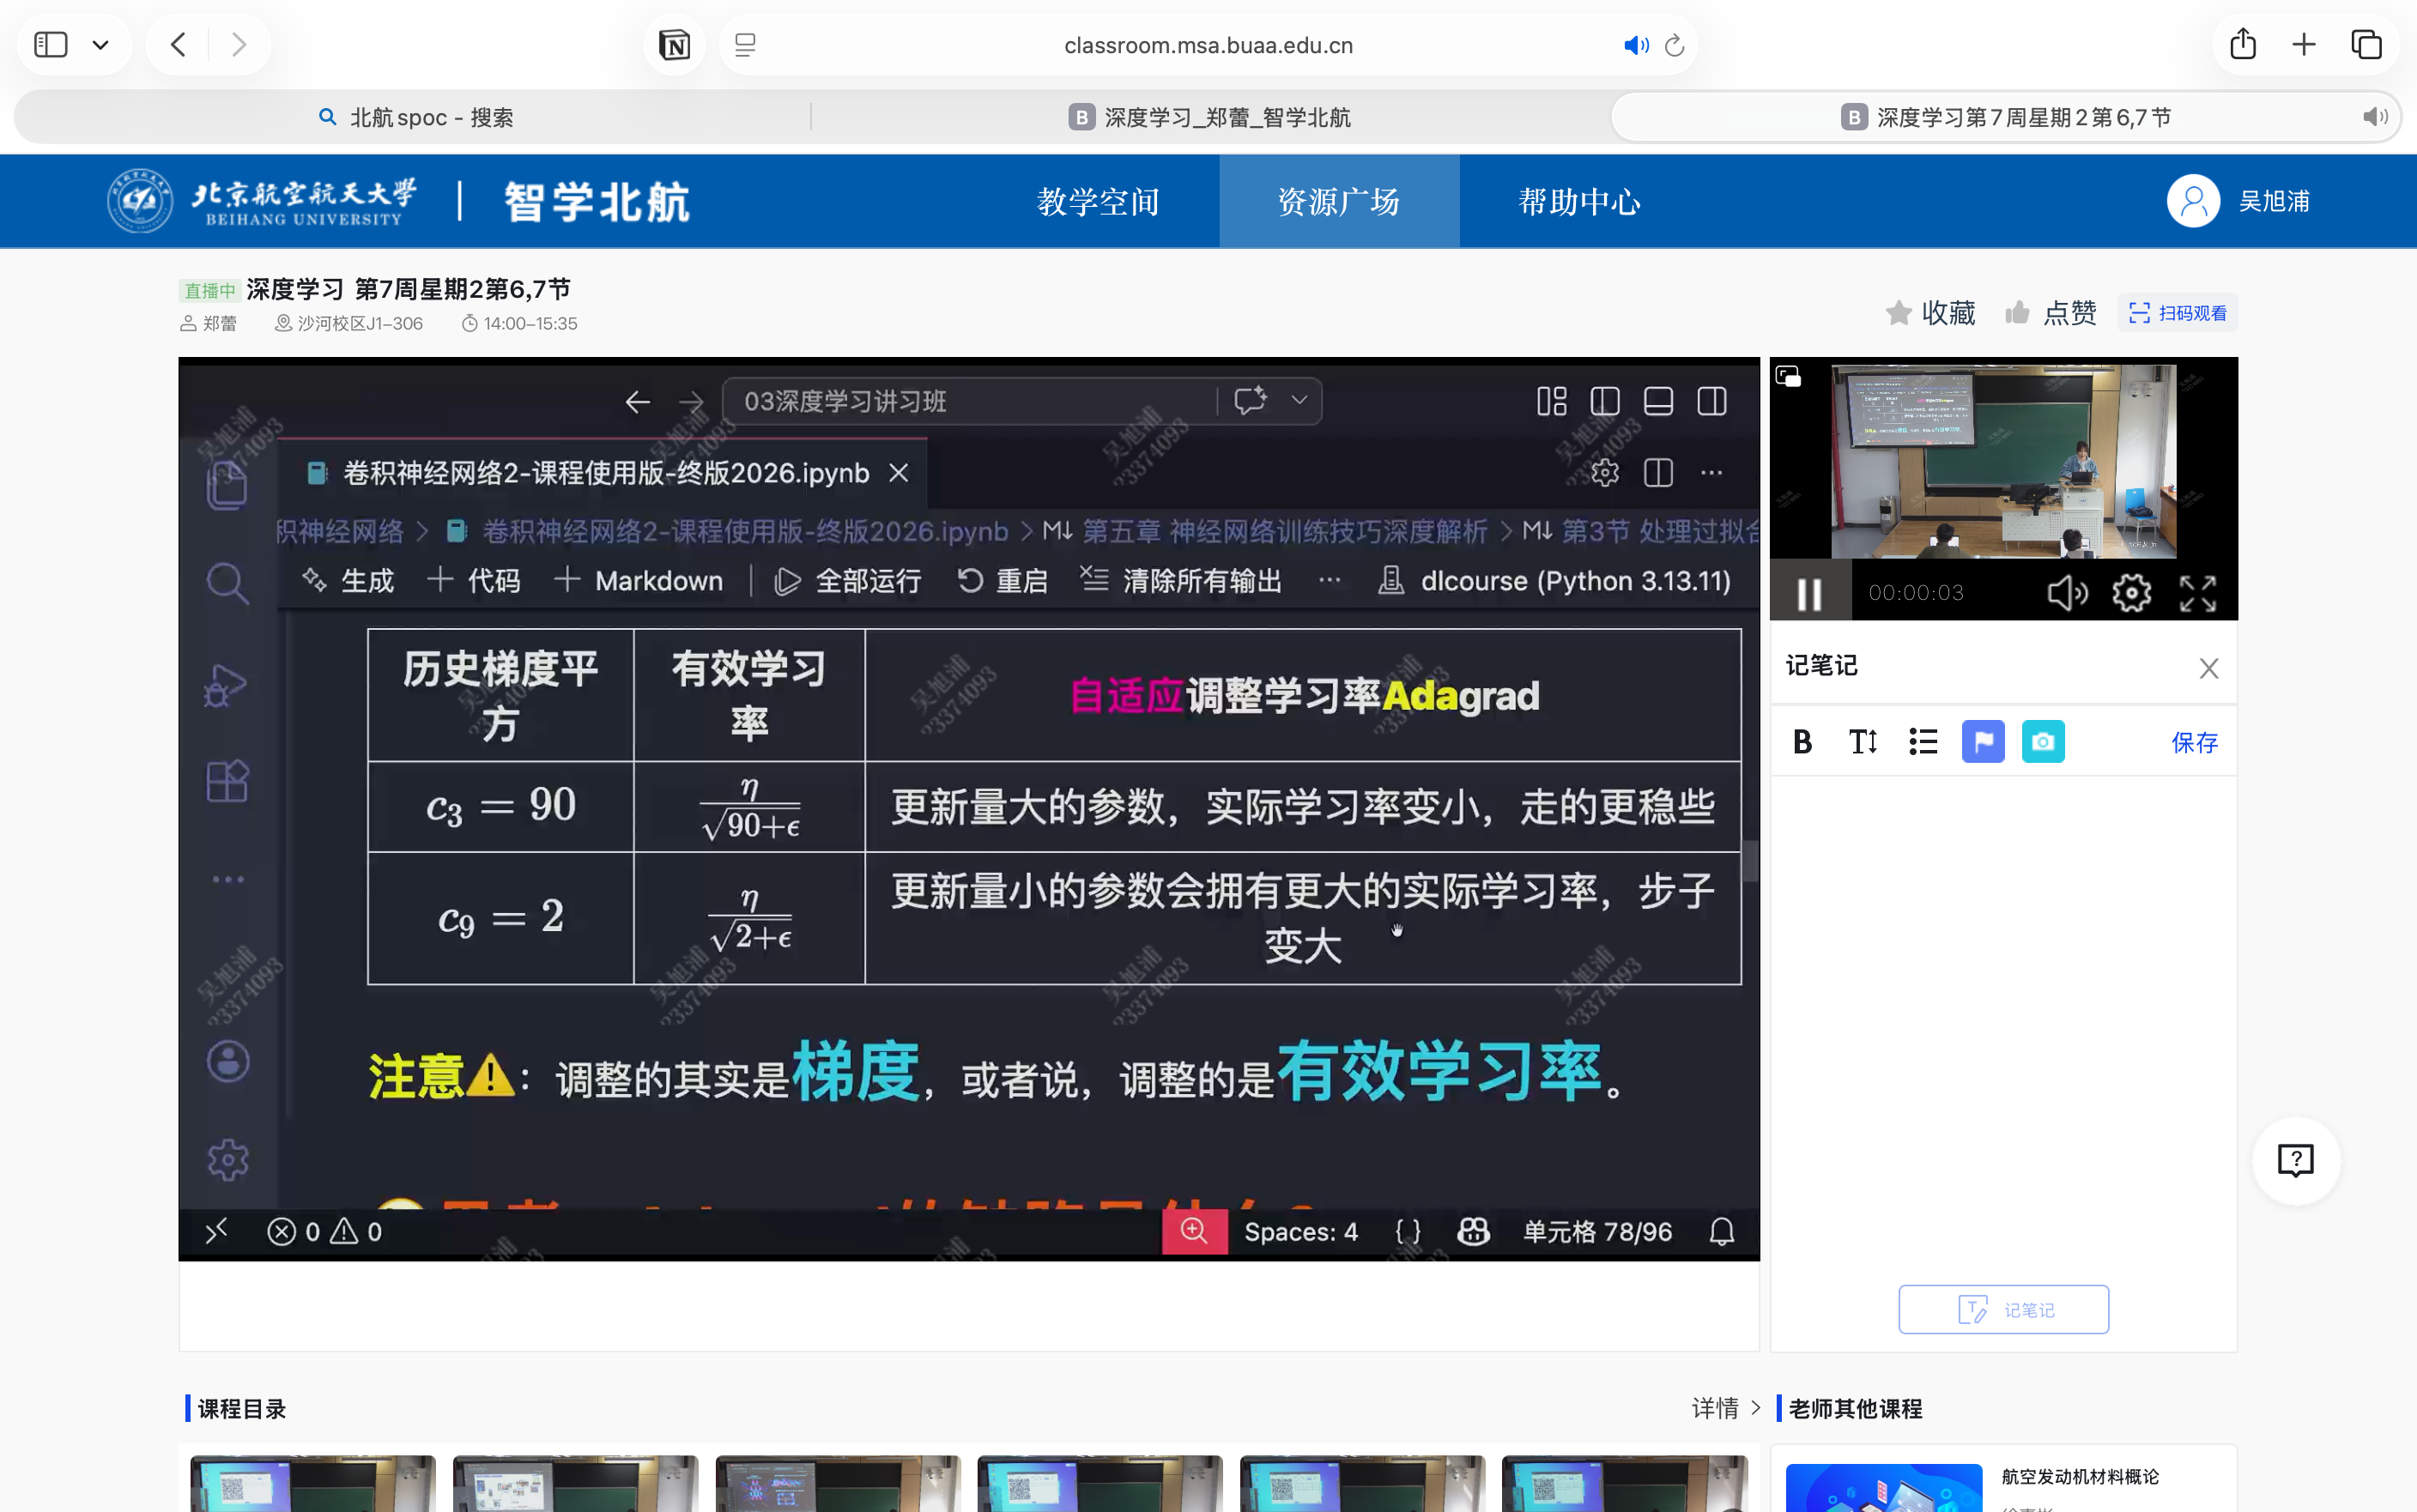

<font color="#f6ff00" size=5>**注意⚠️**</font>：调整的其实是梯度，或者说，调整的是有效学习率。

 ### <font color="#FF6B00" size=6>**🤔思考：Adagrad的缺陷是什么？**</font>
 ￼

#### <font color="#CCFF00">**RMSProp**</font>

RMSProp算法在Adagrad的基础上提出改进，以解决学习率单调下降的问题。

引入<font color="#f6ff00">**遗忘因子$\gamma$**</font>:


$$\boldsymbol{c}=\gamma \boldsymbol{c}+(1-\gamma) \boldsymbol{g}^{2}$$
$$\boldsymbol{\theta}=\boldsymbol{\theta}-\eta \frac{\boldsymbol{g}}{\sqrt{\boldsymbol{c}+\epsilon}}$$

其中：
- $\gamma$为遗忘因子，通常取0.9, 0.99, 0.999

RMSProp仍然根据梯度的大小来调整学习率，但是不同于Adagrad，通过遗忘因子的参与，仅考虑最近几步梯度平方的积累

#### <font color="#CCFF00">**Adagrad versus RMSProp**</font>

<font color="#FF00A0">**Adagrad**</font>：

$$
  \begin{aligned}
  \boldsymbol{c}(t) &= \boldsymbol{c}(t-1)+\boldsymbol{g}(t)^{2} \\
                    &= \boldsymbol{c}(0)+\boldsymbol{g}(1)^{2}+\boldsymbol{g}(2)^{2}+\ldots+\boldsymbol{g}(t)^{2}
  \end{aligned}
  $$

- $\boldsymbol{g}(1)^{2}, \dots,\boldsymbol{g}(t)^{2}$平等贡献于$\boldsymbol{c}(t)$

<font color="#FF00A0">**RMSProp**</font>:

$$
  \begin{aligned}
  \boldsymbol{c}(t) &= \gamma \boldsymbol{c}(t-1) + (1-\gamma) \boldsymbol{g}(t)^{2} \\
                    &= \gamma^{t} \boldsymbol{c}(0) + \gamma^{t-1}(1-\gamma) \boldsymbol{g}(1)^{2} + \gamma^{t-2}(1-\gamma) \boldsymbol{
  g}(2)^{2} + \ldots \\
  &+ \gamma(1-\gamma) \boldsymbol{g}(t-1)^{2}+(1-\gamma) \boldsymbol{g}(t)^{2}
  \end{aligned}
  $$

- 对于$k \ll t$，$\boldsymbol{g}(k)^{2}$对$\boldsymbol{c}(t)$的贡献<font color="#FF00A0">**指数级衰减**</font>

RMSProp没有考虑动量，为RMSProp引入动量--><font color="#f6ff00">**Adam**</font>

#### <font color="#CCFF00">**Adam优化器**</font>

由Kingma and Ba (2015)提出，结合了**动量**和**自适应学习率**：

**一阶矩估计**（动量）：

$$\boldsymbol{m}_t = \beta_1 \boldsymbol{m}_{t-1} + (1-\beta_1) \boldsymbol{g}_t$$

**二阶矩估计**（自适应学习率）：

$$\boldsymbol{c}_t = \beta_2 \boldsymbol{c}_{t-1} + (1-\beta_2) \boldsymbol{g}_t^2$$

**参数更新**：

$$
\boldsymbol{\theta}_t = \boldsymbol{\theta}_{t-1} - \eta \frac{\boldsymbol{m}_t}{\sqrt{\boldsymbol{c}_t + \epsilon}}
$$

其中$\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$是默认值。

**完整形式（偏差修正项）**：缓解优化初期的数值不稳定现象，$\boldsymbol{m}$和$\boldsymbol{c}$都非常小，可能出现0/0的不稳定情况

$$\boldsymbol{m}=\beta_{1} \boldsymbol{m}+\left(1-\beta_{1}\right) \boldsymbol{g}, \boldsymbol{m}_{t}=\boldsymbol{m} /\left(\mathbf{1}-\beta_{1}^{t}\right)$$
$$\boldsymbol{c}=\beta_{2} \boldsymbol{c}+\left(1-\beta_{2}\right) \boldsymbol{g}^{2}, \boldsymbol{c}_{t}=\boldsymbol{c} /\left(\mathbf{1}-\beta_{2}^{t}\right)$$
$$\boldsymbol{\theta}=\boldsymbol{\theta}-\eta \frac{\boldsymbol{m}_{t}}{\sqrt{\boldsymbol{c}_{t}+\epsilon}}$$

- ￼$t$表示迭代次数

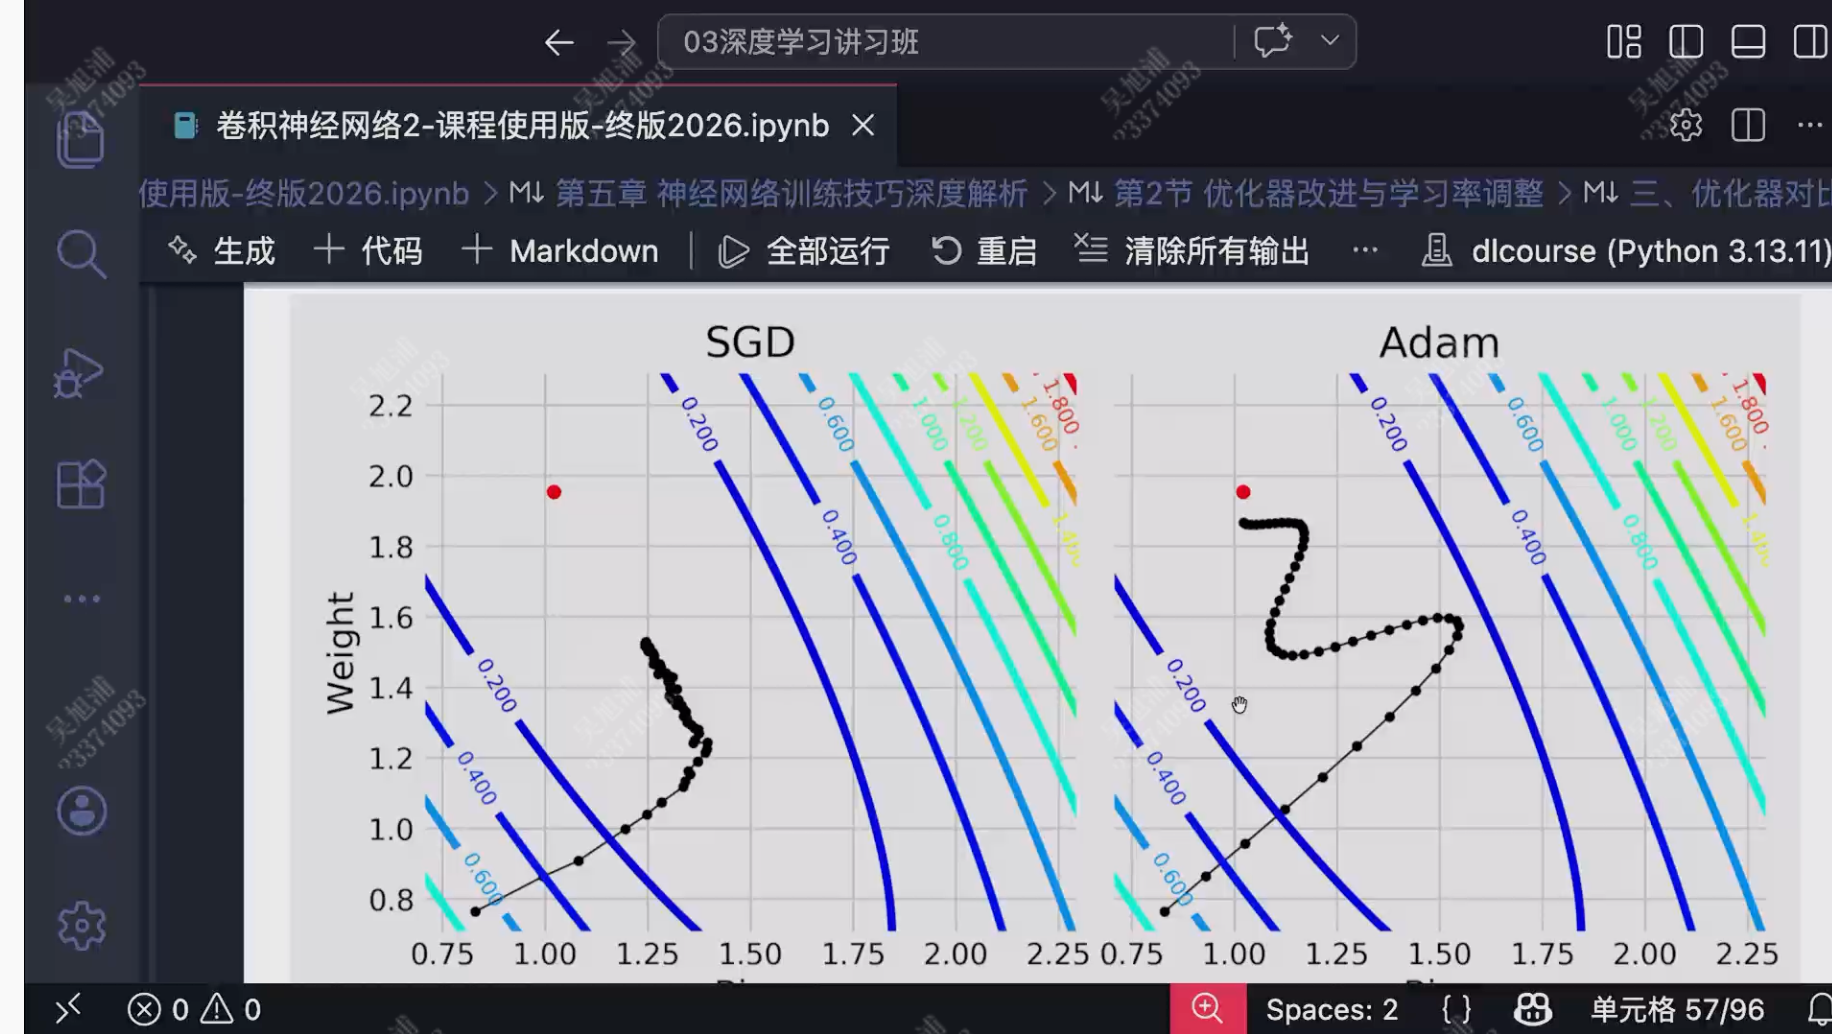

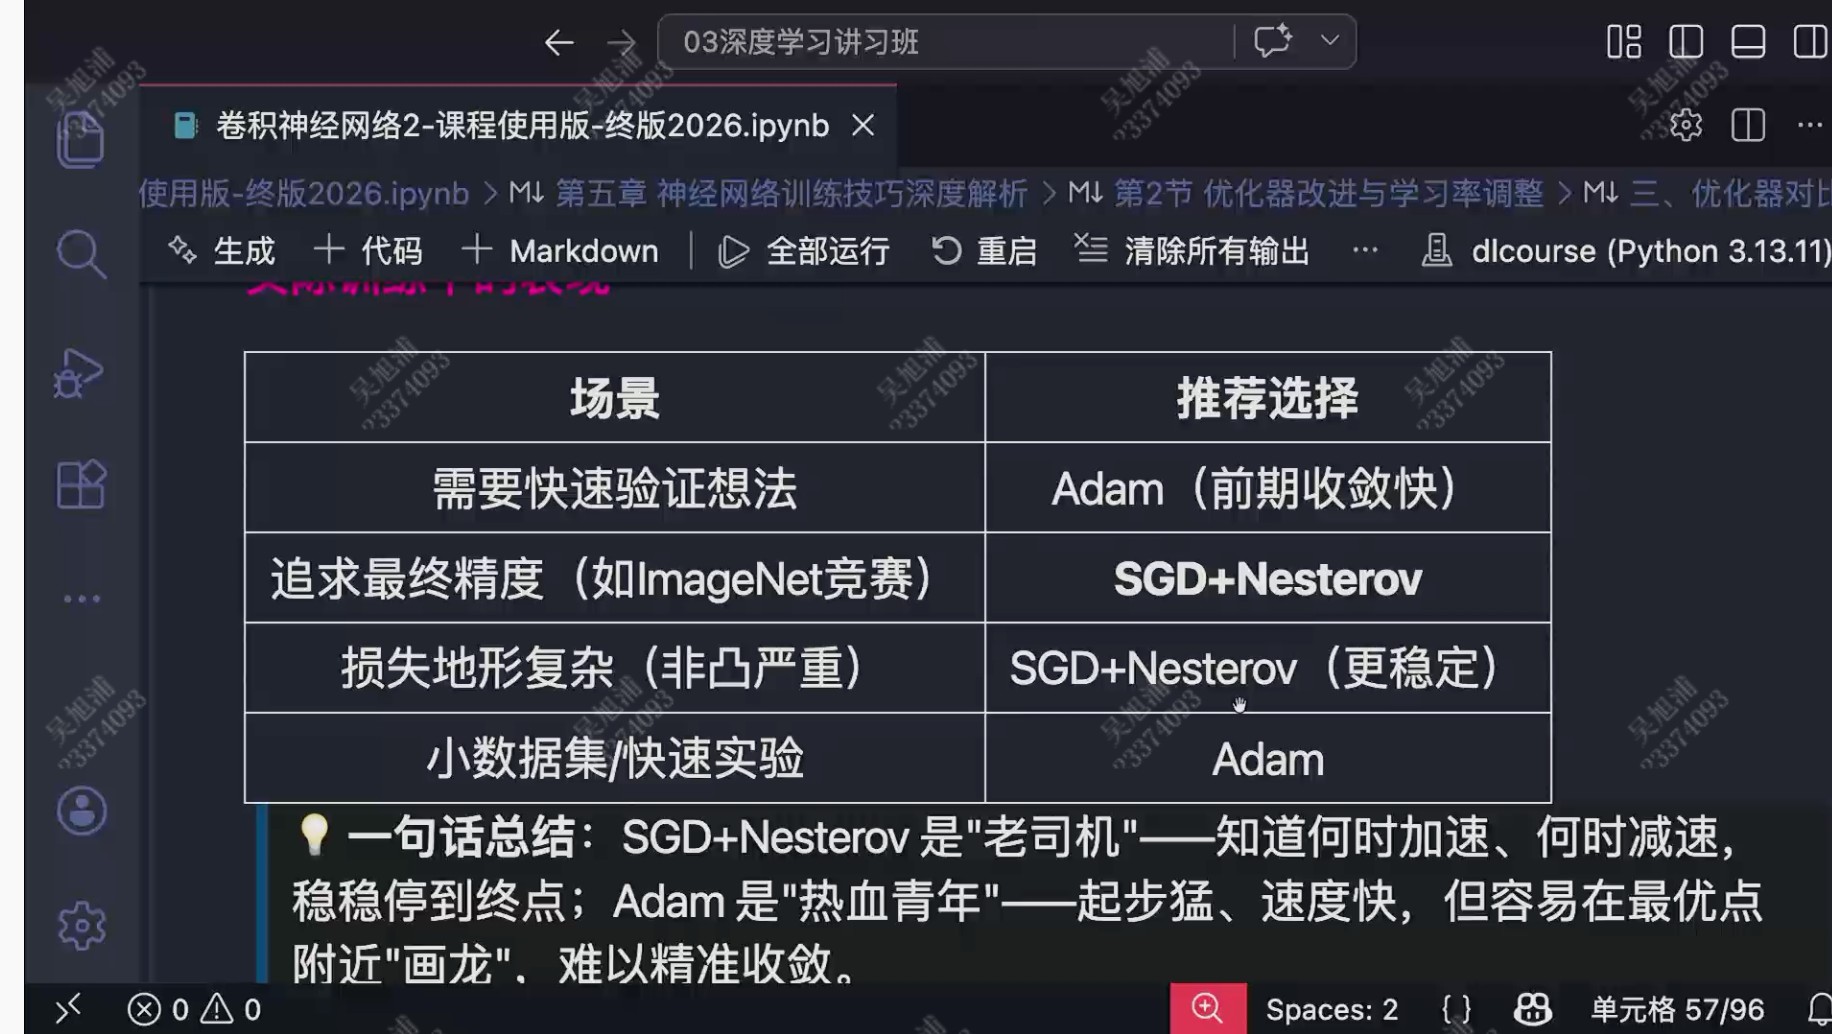


### **<font color="#39FF14" size=6 >三、优化器对比</font>**

| 优化器 | 核心思想 | 特点 | 适用场景 |
|:------:|:--------:|:----:|:--------:|
| **SGD** | 基础梯度下降 | 简单，可能需要调整学习率 | 大规模数据、最终精调 |
| **SGD+Momentum** | 引入动量 | 加速收敛，减少震荡；Nesterov变体可避免冲过头 | CV任务（ResNet等）|
| **Adagrad** | 累积梯度平方 | 自适应学习率，但后期学习率过小（被动早停）| 稀疏数据（早期NLP）|
| **RMSProp** | 遗忘因子/指数移动平均（EMA）| 引入遗忘因子，解决Adagrad学习率单调下降 | RNN、序列模型 |
| **Adam** | Momentum + RMSProp + 偏差修正 | ⭐ **最常用，默认首选**，结合两者优点并修正偏差 | 通用场景、快速实验 |


### **<font color="#39FF14" size=6 >四、学习率调度器</font>**

#### <font color="#CCFF00">**学习率调度的重要性**</font>

至此，我们已经介绍了多种<font color="#FF00A0">**自适应优化器**</font>（SGD+Momentum、RMSProp、Adam），它们的核心能力是：**根据梯度历史，自动调整每个参数的更新幅度**。

但还有一个问题没有解决：**所有参数共享同一个全局学习率 $\eta$**。如果 $\eta$ 固定，训练过程中可能出现问题。

<font color="#FF00A0">**解决方案**</font>：让学习率随训练过程动态变化——这就是<font color="#FF00A0">**学习率调度器（Learning Rate Scheduler）**</font>。

**优化器 + 学习率调度器 = 完整的训练策略**
- 优化器负责'怎么走'（方向和步长的自适应调整）
- 调度器负责'走多快'（全局学习率的阶段性调整）

| 维度 | 优化器（Optimizer） | 学习率调度器（Scheduler） |
|:----:|:-------------------:|:-------------------------:|
| **调整对象** | 每个参数的更新幅度 | 全局学习率 $\eta$ |
| **调整依据** | 梯度历史 | 训练 epoch/损失曲线 |
| **典型代表** | Adam、RMSProp | StepLR、CosineAnnealing |
| **关系** | 相乘关系：$\Delta \theta = -\eta_{scheduler} \times g_{optimizer}$  |

<font color="#FF00A0">**公式解释**</font>：

| 符号 | 含义 | 由谁控制 |
|:----:|:----:|:--------:|
| $\Delta \theta$ | 参数最终更新量 | 两者共同决定 |
| $\eta_{scheduler}$ | 全局学习率 | 学习率调度器（随epoch变化）|
| $g_{optimizer}$ | 优化器输出的有效梯度 | 优化器（自适应调整）|

训练过程中，对学习率的需求：

| 训练阶段 | 学习率需求 | 原因 |
|:--------:|:----------:|:----:|
| **初期** | 较大 | 快速接近最优解 |
| **中期** | 中等 | 稳定收敛 |
| **后期** | 较小 | 精细调整，避免震荡 |

<font color="#FF00A0" >**核心思想**</font>：随着训练进行，逐渐降低学习率

#### <font color="#CCFF00">**PyTorch常用调度器对比**</font>

| 调度器 | 策略 | 关键参数 | 适用场景 |
|:------:|:----:|:--------:|:--------:|
| **StepLR** | 每隔N个epoch，lr×gamma | `step_size`, `gamma` | 周期性调整 |
| **MultiStepLR** | 在指定里程碑调整 | `milestones`, `gamma` | 关键节点调整 |
| **ExponentialLR** | 每个epoch指数衰减 | `gamma` | 平滑衰减 |
| **ReduceLROnPlateau** | 验证停滞时降低 | `mode`, `factor`, `patience` | 自适应调整 |
| **CosineAnnealingLR** | 余弦退火衰减 | `T_max`, `eta_min` | 周期性训练 |

<font color="#CCFF00">**使用频率（实际项目经验）**</font>：

**ReduceLROnPlateau** > CosineAnnealingLR > StepLR > MultiStepLR > ExponentialLR

In [7]:
"""
完整训练示例：使用 ReduceLROnPlateau 学习率调度器

本示例展示如何在 PyTorch 中使用学习率调度器自动调整学习率，
当验证损失不再下降时，自动降低学习率以帮助模型更好地收敛。
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt


def train_with_scheduler(model, train_loader, val_loader, criterion, 
                         optimizer, scheduler, n_epochs=50):
    """
    使用 ReduceLROnPlateau 学习率调度器的训练函数
    
    参数说明:
        model (nn.Module): 神经网络模型，需要训练的网络
        train_loader (DataLoader): 训练数据集的数据加载器，用于批量获取训练数据
        val_loader (DataLoader): 验证数据集的数据加载器，用于评估模型并决定是否降低学习率
        criterion: 损失函数，如 nn.CrossEntropyLoss()，用于计算预测值与真实值的差距
        optimizer (Optimizer): 优化器，如 SGD 或 Adam，负责根据梯度更新模型参数
        scheduler (ReduceLROnPlateau): 学习率调度器，本示例特指 ReduceLROnPlateau
                                       当验证损失停滞时自动降低学习率
        n_epochs (int): 训练的总轮数（epoch），即完整遍历训练集的次数，默认为50
    
    返回值:
        train_losses (list): 每轮训练的平均损失列表，用于观察训练过程是否收敛
        val_losses (list): 每轮验证的平均损失列表，用于判断模型是否过拟合
        learning_rates (list): 每轮的学习率数值列表，用于观察调度器何时、如何调整学习率
    """
    
    # ========== 初始化记录列表 ==========
    train_losses = []      # 记录每轮训练损失，用于后续绘制训练曲线
    val_losses = []        # 记录每轮验证损失，用于判断模型泛化能力和调度器触发时机
    learning_rates = []    # 记录每轮的学习率，关键！用于观察调度器是否正常工作、何时触发
    
    # ========== 开始训练循环 ==========
    for epoch in range(n_epochs):
        
        # ========== 训练阶段 ==========
        # 将模型设置为训练模式，这会启用 Dropout、BatchNorm 等层的训练行为
        model.train()
        train_loss = 0.0   # 累积本轮所有batch的训练损失，最后求平均
        
        for inputs, targets in train_loader:
            # 标准训练四步曲：
            # Step 1: 清零梯度。重要！因为 PyTorch 默认梯度累积，不清零会导致梯度叠加错误
            optimizer.zero_grad()
            
            # Step 2: 前向传播。将输入数据传入模型，得到预测输出
            outputs = model(inputs)
            
            # Step 3: 计算损失。使用损失函数衡量预测值与真实目标的差距
            loss = criterion(outputs, targets)
            
            # Step 4: 反向传播。计算损失函数对模型参数的梯度（即损失对各参数的偏导数）
            loss.backward()
            
            # Step 5: 参数更新。优化器根据计算出的梯度，使用当前学习率更新模型参数
            optimizer.step()
            
            # 累积本轮损失值（使用 .item() 将 tensor 转为 Python 数值，避免内存占用）
            train_loss += loss.item()
        
        # 计算本轮平均训练损失 = 总损失 / batch 数量
        train_loss /= len(train_loader)
        train_losses.append(train_loss)  # 保存到列表，用于后续绘图
        
        
        # ========== 验证阶段 ==========
        # 将模型设置为评估模式，禁用 Dropout，BatchNorm 使用训练时的移动平均统计量
        model.eval()
        val_loss = 0.0     # 累积本轮验证损失
        
        # 使用 torch.no_grad() 上下文管理器，禁用梯度计算
        # 目的：1. 节省显存  2. 加速计算（不需要反向传播）
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)              # 前向传播得到预测
                loss = criterion(outputs, targets)   # 计算验证损失
                val_loss += loss.item()              # 累积损失
        
        # 计算本轮平均验证损失
        val_loss /= len(val_loader)
        val_losses.append(val_loss)  # 保存到列表
        
        
        # ========== 学习率调度（核心部分！）==========
        
        # Step 1: 记录当前学习率
        # optimizer.param_groups[0] 是优化器的第一个参数组（通常只有一个）
        # ['lr'] 是该参数组的当前学习率数值
        # 为什么要记录？用于后续观察学习率变化曲线，验证调度器是否按预期工作
        current_lr = optimizer.param_groups[0]['lr']
        learning_rates.append(current_lr)
        
        # Step 2: 调用学习率调度器
        # ReduceLROnPlateau 的工作原理：
        # - 它会跟踪传入的指标（这里是 val_loss）
        # - 如果连续 `patience` 轮指标没有改善（即验证损失不再下降）
        # - 自动将学习率乘以 `factor`（如乘以 0.1，即降低10倍）
        # - 为什么传 val_loss？因为我们要根据模型在验证集上的表现来决定是否降低学习率
        scheduler.step(val_loss)
        
        
        # ========== 打印训练进度 ==========
        # 每 10 轮打印一次当前状态，包括轮数、训练损失、验证损失、当前学习率
        # 观察学习率的变化可以知道调度器是否触发了学习率降低
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{n_epochs}], '
                  f'Train Loss: {train_loss:.4f}, '
                  f'Val Loss: {val_loss:.4f}, '
                  f'LR: {current_lr:.6f}')
    
    # 返回三个列表，用于后续分析和可视化
    return train_losses, val_losses, learning_rates


# ========== 使用示例 ==========
print("=" * 60)
print("训练函数定义完成！")
print("=" * 60)

print("""
【使用示例 - ReduceLROnPlateau 调度器】

# Step 1: 准备模型、损失函数和优化器
model = MyModel()                           # 你的神经网络模型
criterion = nn.CrossEntropyLoss()           # 分类任务常用损失函数
optimizer = optim.SGD(model.parameters(),    # 要优化的参数
                     lr=0.1)                 # 初始学习率，设大一些以便后续降低

# Step 2: 创建 ReduceLROnPlateau 调度器
# 这是最关键的一步！参数说明：
#   mode='min'      : 监测指标是越小越好（如损失），若监测准确率则用 'max'
#   factor=0.1        : 学习率降低的倍数，新学习率 = 旧学习率 × 0.1（即降低10倍）
#   patience=5        : 容忍轮数，若连续5轮验证损失不下降，才降低学习率
#   verbose=True      : 打印学习率调整信息，方便观察调度器何时触发
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min',          
    factor=0.1, 
    patience=5, 
    verbose=True
)

# Step 3: 开始训练
train_losses, val_losses, learning_rates = train_with_scheduler(
    model=model,                # 神经网络模型
    train_loader=train_loader,  # 训练数据加载器（batch化的训练数据）
    val_loader=val_loader,      # 验证数据加载器（必须有！用于判断何时降学习率）
    criterion=criterion,        # 损失函数
    optimizer=optimizer,        # 优化器
    scheduler=scheduler,        # 学习率调度器
    n_epochs=100                # 训练100轮
)

# Step 4: 可视化训练结果和学习率变化（非常重要！用于诊断）
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 子图1: 绘制训练和验证损失曲线，观察收敛情况
axes[0].plot(train_losses, label='Train Loss', color='blue')
axes[0].plot(val_losses, label='Val Loss', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# 子图2: 绘制学习率变化曲线，观察调度器何时、如何调整学习率
# 这条曲线应该呈现阶梯状下降，每次下降对应验证损失停滞
axes[1].plot(learning_rates, label='Learning Rate', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].set_title('Learning Rate Schedule (ReduceLROnPlateau)')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale('log')  # 使用对数刻度，更清楚看学习率变化

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)  # 保存图片
plt.show()

print("\n提示：观察学习率曲线，当验证损失连续5轮不下降时，学习率会自动降低！")
""")


训练函数定义完成！

【使用示例 - ReduceLROnPlateau 调度器】

# Step 1: 准备模型、损失函数和优化器
model = MyModel()                           # 你的神经网络模型
criterion = nn.CrossEntropyLoss()           # 分类任务常用损失函数
optimizer = optim.SGD(model.parameters(),    # 要优化的参数
                     lr=0.1)                 # 初始学习率，设大一些以便后续降低

# Step 2: 创建 ReduceLROnPlateau 调度器
# 这是最关键的一步！参数说明：
#   mode='min'      : 监测指标是越小越好（如损失），若监测准确率则用 'max'
#   factor=0.1        : 学习率降低的倍数，新学习率 = 旧学习率 × 0.1（即降低10倍）
#   patience=5        : 容忍轮数，若连续5轮验证损失不下降，才降低学习率
#   verbose=True      : 打印学习率调整信息，方便观察调度器何时触发
scheduler = ReduceLROnPlateau(
    optimizer, 
    mode='min',          
    factor=0.1, 
    patience=5, 
    verbose=True
)

# Step 3: 开始训练
train_losses, val_losses, learning_rates = train_with_scheduler(
    model=model,                # 神经网络模型
    train_loader=train_loader,  # 训练数据加载器（batch化的训练数据）
    val_loader=val_loader,      # 验证数据加载器（必须有！用于判断何时降学习率）
    criterion=criterion,        # 损失函数
    optimizer=optimizer,        # 优化器
    sc

##  <font color="#FFEA00" >**第3节 处理过拟合的综合策略**</font>

**过拟合的表现**：对训练集拟合得很好，但在验证集表现较差

**原因**：神经网络通常含有大量参数，容易记住训练数据而非学习规律


### **<font color="#39FF14" size=6 >一、早停（Early Stopping）</font>**

当训练损失逐渐下降，但验证集损失逐渐上升时，<font color="#FF00A0">**主动**</font>停止优化。与Adagrad优化引起的“早停”是两回事（被动的）

<font color="#FF00A0" >**早停原理**</font>：
- 监控验证集损失（或准确率）
- 如果连续`patience`个epoch没有改善，停止训练
- 恢复验证集表现最好的模型权重

### <font color="#39FF14" size=6 >**二、Dropout**</font>

Dropout是一种<font color="#FF00A0">**正则化技术**</font>，通过在训练过程中<font color="#FF00A0">**随机**</font>丢弃（输出置零）一定比例神经元来防止过拟合。

<font color="#FF00A0" >**核心思想**</font>：
- 强制模型找到多种路径来达到目标，不能依赖少数特定神经元，防止神经元出现复杂的相互协同（co-adaptations）（团队协作有时候也不一定是好事，总有摸鱼的，神经元会“偷懒”）
- 相当于在合理的时间内训练了大量不同的网络并集成其结果
- 增加模型的鲁棒性和泛化能力

#### <font color="#CCFF00">**Dropout在Train模式和Eval模式的表现</font>**

Dropout在训练和评估阶段的行为**完全不同**：

**训练阶段（train mode）**：
- 以概率$p$随机丢弃神经元（将其输出设为0）
- 保留的神经元输出需要**放大**（乘以$1/(1-p)$）
- 每次前向传播丢弃的神经元都不同

**评估阶段（eval mode）**：
- 使用**所有**神经元
- 不进行任何丢弃操作
- 输出与训练时保持一致的期望值

#### <font color="#CCFF00">**为什么需要缩放？**</font>

缩放因子$1/(1-p)$的目的是**保持输出的期望值一致**。

**举例说明**（假设p=0.5）：
- 训练时，平均有50%的神经元被保留，每个保留的神经元输出×2
- 评估时，100%的神经元参与计算，不进行缩放
- 这样两种模式下的输出期望相同，确保模型行为一致

💡 输出分布的方差随着丢弃概率的增加而增加。较高的丢弃概率会使模型更难学习——这就是正则化的作用。

#### <font color="#CCFF00">**卷积层特殊的nn.Dropout2d**</font>

普通的`nn.Dropout`会随机丢弃**单个像素值**，但对于卷积层：
- 相邻像素高度相关（空间相关性）
- 随机丢弃单个像素影响不大，可以用周围像素插值
- 需要一种更强的正则化方式

<font color="#FF00A0" >**解决方案**</font>：`nn.Dropout2d`
- 以概率$p$**丢弃整个通道**（feature map）
- 保留的通道所有像素值不变
- 对RGB图像而言，相当于随机丢弃某种颜色通道

#### <font color="#CCFF00">**Dropout正则化效果**</font>


<font color="#CCFF00">**Dropout概率选择建议**</font>

| 层位置 | 推荐概率 | 说明 |
|:------:|:--------:|:----:|
| **输入层** | 0.1-0.2 | 不要轻易丢弃原始输入信息 |
| **隐藏层（全连接）** | 0.3-0.5 | 最常用的配置，0.5是Hinton推荐值 |
| **CNN卷积层** | 一般不用或使用Dropout2d(p=0.1) | 卷积层参数共享，本身有正则化效果 |
| **RNN/LSTM** | 0.2-0.3 | 或使用变分Dropout，时间序列需小心 |

💡 **实践经验**：从0.5开始，如果过拟合严重增加到0.7，如果欠拟合减少到0.3。

### <font color="#39FF14" size=6 >**三、数据增强（Data Augmentation）**</font>

除了从模型结构（Dropout）和训练策略（早停）防止过拟合，还可以从数据层面入手——通过数据增强扩充训练集的多样性


- $\left\{\boldsymbol{x}^{(n)}, \boldsymbol{t}^{(n)}\right\}$表示原本的训练集
- 在输入数据中加入一些变换$\boldsymbol{x}^{(n)} \rightarrow \hat{\boldsymbol{x}}^{(n)}$，标签$\boldsymbol{t}^{(n)}$保持不变
- 使用增强后的训练集$\left\{\boldsymbol{x}^{(n)}, \boldsymbol{t}^{(n)}\right\} \cup\left\{\hat{\boldsymbol{x}}^{(n)}, \boldsymbol{t}^{(n)}\right\}$来训练模型
- 不同数据类型（文本，图像，视频）有不同的变换

#### <font color="#CCFF00">**计算机视觉女神Lenna**</font>

- IEEE 计算机协会宣布，2024年4月1日起不再接收包含该图像的论文。
- IEEE技术&会议活动副主席Terry Benzel在邮件里这样写道：IEEE本着坚持促进开放、包容及公平文化的承诺，同时尊重照片主体Lena Forsen本人的意愿，决定不再接收包含Lenna图像的论文。

#### <font color="#CCFF00">**图像数据增强方式**</font>
| 变换类型 | 说明 |
|:--------|:----|
| **翻转（Flip）** | 水平或垂直翻转 |
| **平移（Translation）** | 图像位置移动 |
| **缩放（Scale）** | 裁剪和缩放 |
| **旋转（Rotation）** | 图像旋转 |
| **色彩变换** | 调整亮度、对比度等 |
| **Cutout/Erasing** | 随机擦除部分区域 |

In [ ]:
# 数据增强代码示例（PyTorch）
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 定义数据增强变换组合
transform = transforms.Compose([
    # 随机水平翻转，概率50%
    transforms.RandomHorizontalFlip(p=0.5),
    
    # 随机旋转，角度范围-10到+10度
    transforms.RandomRotation(degrees=10),
    
    # 随机裁剪后缩放到指定大小
    transforms.RandomResizedCrop(size=224, scale=(0.8, 1.0)),
    
    # 色彩抖动：随机调整亮度、对比度、饱和度
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    
    # 转换为Tensor
    transforms.ToTensor(),
])

# 使用示例
# image = Image.open('lena.png')
# augmented_image = transform(image)

### <font color="#39FF14" size=6 >**四、增加权重衰减（Weight Decay）**</font>

#### <font color="#CCFF00">**什么是权重衰减？**</font>

权重衰减（Weight Decay），也称为<font color="#FF00A0">**L2正则化**</font>，是一种通过在损失函数中添加参数惩罚项来防止过拟合的技术。

**数学原理**：
$$L_{total} = L_{loss} + \lambda \sum_{i} \theta_i^2$$

其中：
- $L_{loss}$：原始损失（如交叉熵损失）
- $\lambda$：权重衰减系数（正则化强度）
- $\sum \theta_i^2$：所有参数平方和

**作用机制**：
- 惩罚大的参数值，鼓励模型使用更小的权重
- 限制模型的复杂度，防止对训练数据过度拟合
- 等价于在参数更新时额外减去一个与参数成正比的项

In [13]:
# 权重衰减（Weight Decay）代码示例
import torch
import torch.nn as nn
import torch.optim as optim

# 定义模型
model = nn.Sequential(
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

# ========== 方式1: 在优化器中设置weight_decay ==========
# weight_decay就是L2正则化的lambda系数
# 常见取值：1e-4, 5e-4, 1e-3

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,              # 学习率
    momentum=0.9,         # 动量
    weight_decay=1e-4     # 权重衰减系数（L2正则化）
)

# Adam优化器同样支持weight_decay
optimizer_adam = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4     # L2正则化
)

print("权重衰减设置完成！")
print("\n推荐配置：")
print("  - SGD + weight_decay: 1e-4 ~ 5e-4")
print("  - Adam + weight_decay: 1e-4 ~ 1e-3")
print("  - 与Dropout一起使用效果更好")

权重衰减设置完成！

推荐配置：
  - SGD + weight_decay: 1e-4 ~ 5e-4
  - Adam + weight_decay: 1e-4 ~ 1e-3
  - 与Dropout一起使用效果更好


### <font color="#39FF14" size=6 >**五、处理过拟合策略总结**</font>

| 策略 | 作用层面 | 实现方式 | 适用场景 | 推荐程度 |
|:----:|:--------:|:--------:|:--------:|:--------:|
| **早停（Early Stopping）** | 训练流程 | 监控验证损失，不改善则停止 | 所有模型 | ⭐⭐⭐⭐⭐ |
| **Dropout** | 模型结构 | 训练时随机丢弃神经元 | 全连接层必备 | ⭐⭐⭐⭐⭐ |
| **Dropout2d** | 模型结构 | 训练时随机丢弃通道 | 卷积层 | ⭐⭐⭐⭐ |
| **权重衰减（L2）** | 损失函数 | 添加参数惩罚项 | 所有模型 | ⭐⭐⭐⭐⭐ |
| **数据增强** | 数据输入 | 图像变换扩充数据 | 图像任务必备 | ⭐⭐⭐⭐⭐ |

<font color="#FF00A0">**组合使用建议**</font>：

对于图像分类任务，推荐同时使用：
```
Dropout(0.5) + Weight Decay(1e-4) + Early Stopping + Data Augmentation
```

各策略之间的关系：
- **Dropout**和**权重衰减**：互补关系，Dropout随机失活，权重衰减限制参数大小
- **早停**：防止训练过度的最后一道防线
- **数据增强**：从源头增加数据多样性，减轻模型记忆压力

##  <font color="#FFEA00" >**第4节 超参数选取实践指南**</font>

### **<font color="#39FF14" size=6 >超参数类型</font>**

| 类别 | 具体参数 |
|:----:|:--------:|
| **模型架构** | 层数、每层的神经元数目 |
| **训练参数** | 学习率、批量大小（batch size） |
| **正则化** | 权重衰减率（weight decay）、Dropout率 |
| **优化器** | 动量系数、Adam的$\beta$参数 |

### **<font color="#39FF14" size=6 >六步实践指南</font>**

由Fei-Fei Li & Justin Johnson & Serena Yeung （CS231n 2019, Stanford University）给出的建议

#### <font color="#CCFF00">**第1步：观察初始损失**</font>
- 确保损失计算正确
- 将权重衰减设为零

#### <font color="#CCFF00">**第2步：在小样本上过拟合**</font>
- 在少量样本上训练，尝试达到100%训练准确率
- 验证整个流程是否正确
- 如果损失不下降：初始化不好、学习率太小、模型太小
- 如果损失为Inf/NaN：初始化不好、学习率太大

#### <font color="#CCFF00">**第3步：找到使损失下降的学习率**</font>
- 当损失下降较慢时，将学习率缩小10倍
- 使用较小的权重衰减

#### <font color="#CCFF00">**第4步：粗粒度搜索**</font>
- 尝试接近的学习率和衰减率（1e-4, 1e-5, 0）
- 训练1-5轮

#### <font color="#CCFF00">**第5步：细粒度搜索**</font>
- 使用最好的学习率，训练更长时间（10-20轮）

#### <font color="#CCFF00">**第6步：观察损失曲线**</font>
- 使用滑动平均绘制训练损失
- 检查是否存在病态曲率（反复震荡）

<font color="#CCFF00">**损失曲线诊断指南**</font>

根据训练曲线的不同模式，可以诊断出以下常见问题：

| 曲线模式 | 问题诊断 | 解决方案 |
|:-----------|:--------|:--------|
| **左上：损失高位徘徊后突然下降** | 不好的初始化 | 使用Xavier/He初始化或批归一化（BN）|
| **右上：损失震荡且收敛慢（平台期）**| 病态曲率 | 使用Momentum或学习率衰减 |
| **左下：训练准确率↑ 验证准确率→或↓** | **过拟合** | 增加数据、提升正则化（Dropout/Weight Decay）、早停、使用更小的模型 |
| **右下：训练≈验证（都很低）** | **欠拟合** | 使用更大的模型、训练更久、降低正则化 |

<font color="#FF00A0">**判断标准**</font>：
- **过拟合**：训练准确率 >> 验证准确率（差距大，通常>5%）
- **欠拟合**：训练准确率 ≈ 验证准确率（都很低，通常<70%）
- **好的拟合**：训练准确率略高于验证准确率（差距2-5%），且两者都较高

💡 <font color="#FF00A0" >**经验很重要！**</font>多实践、多观察损失曲线，才能找到最佳超参数。

##  <font color="#FFEA00" >**本章总结**</font>

### 核心知识点回顾

**第一部分：梯度消失与梯度爆炸及解决方案**
- **梯度消失**：深层网络中靠近输入层的梯度逐层减小→0，导致浅层无法学习
- **梯度爆炸**：梯度指数级增长，损失变为NaN，常见于深层网络和RNN
- **梯度裁剪**：Value Clipping（元素级）、Norm Clipping（范数裁剪）、Backward Hooks（RNN专用）
- **梯度爆炸治本方案**：批归一化（BN/LN）、权重正则化、改进初始化（Fixup/正交初始化）
- **梯度消失解决方案**：Xavier初始化（Tanh/Sigmoid）、Kaiming/He初始化（ReLU）、批归一化（补偿不良初始化）
- **BN核心机制**：训练用batch统计量，推理用移动平均；对每个通道独立归一化

**第二部分：优化器与学习率调整**
- **病态曲率**：损失函数在某些方向变化陡峭，某些方向平缓，SGD呈锯齿状下降
- **动量（Momentum）**：引入速度概念，加速收敛，减少震荡，γ通常设为0.9
- **Nesterov加速梯度（NAG）**：先展望再计算梯度，提前感知变化，避免冲过头
- **自适应学习率**：Adagrad（累积梯度平方，学习率单调递减）、RMSProp（指数移动平均EMA解决Adagrad问题）、Adam（Momentum+RMSProp+偏差修正）
- **学习率调度器**：StepLR、MultiStepLR、ExponentialLR、ReduceLROnPlateau（最实用，推荐首选）、CosineAnnealingLR
- **优化器与调度器配合**：优化器负责'怎么走'（自适应梯度），调度器负责'走多快'（全局学习率），两者相乘决定最终更新

**第三部分：过拟合处理**
- **早停（Early Stopping）**：监控验证损失，连续patience轮不改善则停止，恢复最佳权重
- **Dropout**：训练时随机丢弃神经元（概率p），保留神经元输出放大1/(1-p)；评估时使用全部神经元
- **Dropout概率选择**：输入层0.1-0.2，隐藏层0.3-0.5，CNN卷积层一般不用或使用Dropout2d(p=0.1)
- **Dropout2d**：丢弃整个通道（feature map），而非单个像素，更适合卷积层
- **数据增强**：翻转、旋转、缩放、裁剪、色彩变换、Cutout/Erasing，扩充训练数据多样性
- **权重衰减（Weight Decay/L2正则化）**：在损失函数中添加参数平方和惩罚项，限制模型复杂度
- **综合策略组合**：Dropout(0.5) + Weight Decay(1e-4) + Early Stopping + Data Augmentation

**第四部分：超参数选择实践指南**
- **超参数分类**：模型架构（层数、神经元数）、训练参数（学习率、batch size）、正则化（weight decay、Dropout率）、优化器（动量系数、Adam的β）
- **六步实践法**：
  1. 观察初始损失（确保损失计算正确，权重衰减设为零）
  2. 在小样本上过拟合（验证流程正确性）
  3. 找到使损失下降的学习率（学习率缩小10倍尝试）
  4. 粗粒度搜索（1-5轮，尝试不同学习率和衰减率）
  5. 细粒度搜索（使用最好学习率，训练10-20轮）
  6. 观察损失曲线（使用滑动平均，诊断病态曲率/过拟合/欠拟合）
- **损失曲线诊断**：
  - 高位徘徊后突然下降：不好的初始化→Xavier/He初始化或BN
  - 震荡且收敛慢：病态曲率→Momentum或学习率衰减
  - 训练↑验证↓：过拟合→正则化、早停、更多数据
  - 训练≈验证（都很低）：欠拟合→更大模型、训练更久

### 实践建议

1. **遇到梯度问题**：先检查激活函数和初始化，再考虑批归一化；梯度爆炸优先使用BN（治本），梯度裁剪作为保险（治标）
2. **选择优化器**：大部分情况下Adam是不错的起点（默认β₁=0.9, β₂=0.999）；SGD+Momentum（特别是+Nesterov）往往能达到更好的最终精度，适合CV任务
3. **学习率调整**：优先使用ReduceLROnPlateau（根据验证集表现自适应调整），配合优化器使用
4. **防止过拟合**：Dropout(0.5) + 早停 + 数据增强 + 权重衰减(1e-4)是多管齐下的有效策略
5. **超参数调优**：系统化调参（六步法），记录实验，一次只改一个变量，对比结果
6. **训练监控**：务必记录并可视化训练/验证损失曲线和学习率变化，用于诊断问题